# Phase C results — IF sampling evaluation reader

**Purpose.** Load the three parquet outputs produced by `scripts/evaluate_phase_c.py`
(immunogenicity-head, immunogenicity-NMP, structural) for a single Phase C run
and surface the distributions, joint structure, and per-protein leaderboards.

Default: `data/0401native/` (allele DRB1\*04:01, native arm = Module K unbiased).
Override `RESULT_DIR` to point at any future eval output sharing the same schema
(`inverse_folding/evaluation/schema.py` — `STRUCTURAL_COLUMNS`,
`IMMUNOGENICITY_HEAD_COLUMNS`, `IMMUNOGENICITY_NMP_COLUMNS`).

Join key: `(protein_id, design_id)` — `design_idx` is identical and is dropped
after the merge.

In [ ]:
# Cell 1 — imports + path config.
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.environ.get("PROJECT_ROOT", Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
RESULT_DIR = Path(os.environ.get("RESULT_DIR", PROJECT_ROOT / "data" / "0401native"))
RUN_LABEL = os.environ.get("RUN_LABEL", RESULT_DIR.name)

HEAD_PARQUET = RESULT_DIR / "imm_head.parquet"
NMP_PARQUET  = RESULT_DIR / "imm_nmp.parquet"
STRUCT_PARQUET = RESULT_DIR / "structural.parquet"

for p in (HEAD_PARQUET, NMP_PARQUET, STRUCT_PARQUET):
    if not p.exists():
        raise FileNotFoundError(p)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 24)
print(f"[run] {RUN_LABEL}  dir={RESULT_DIR}")

ModuleNotFoundError: No module named 'pandas'

: 

In [2]:
# Cell 2 — load + schema sanity + join.
from inverse_folding.evaluation.schema import (
    STRUCTURAL_COLUMNS,
    IMMUNOGENICITY_HEAD_COLUMNS,
    IMMUNOGENICITY_NMP_COLUMNS,
    validate_dataframe,
)

df_head = pd.read_parquet(HEAD_PARQUET)
df_nmp  = pd.read_parquet(NMP_PARQUET)
df_struct = pd.read_parquet(STRUCT_PARQUET)

validate_dataframe(df_head, IMMUNOGENICITY_HEAD_COLUMNS)
validate_dataframe(df_nmp,  IMMUNOGENICITY_NMP_COLUMNS)
validate_dataframe(df_struct, STRUCTURAL_COLUMNS)

# Join on (protein_id, design_id). design_idx is redundant after the merge.
key = ["protein_id", "design_id"]
df = (
    df_struct
    .merge(df_head.drop(columns=["design_idx"]), on=key, how="inner", validate="one_to_one")
    .merge(df_nmp.drop(columns=["design_idx"]),  on=key, how="inner", validate="one_to_one")
)
df["sequence_length"] = df["sequence"].str.len()

print(f"head:       {len(df_head):>5d} rows  | columns: {sorted(df_head.columns)}")
print(f"nmp:        {len(df_nmp):>5d} rows  | columns: {sorted(df_nmp.columns)}")
print(f"structural: {len(df_struct):>5d} rows  | columns: {sorted(df_struct.columns)}")
print(f"merged:     {len(df):>5d} rows, {df['protein_id'].nunique()} unique proteins")
print(f"foldability: {df['foldability'].sum()} folded / {len(df) - df['foldability'].sum()} failed")
print(f"refold backends: {df['refold_backend'].value_counts().to_dict() if 'refold_backend' in df.columns else 'n/a'}")
df.head(3)

head:        3072 rows  | columns: ['design_id', 'design_idx', 'global_risk', 'max_hotspot', 'mean_hotspot', 'n_hotspot_positions', 'protein_id']
nmp:         3072 rows  | columns: ['design_id', 'design_idx', 'mean_best_rank', 'n_strong_binders', 'n_weak_binders', 'n_windows_scored', 'protein_id']
structural:  3072 rows  | columns: ['bb_RMSD', 'design_id', 'design_idx', 'foldability', 'pLDDT', 'protein_id', 'recovery', 'refold_backend', 'scTM', 'sequence']
merged:      3072 rows, 3072 unique proteins
foldability: 2855 folded / 217 failed
refold backends: {'esmfold': 3072}


,protein_id,design_id,design_idx,sequence,scTM,pLDDT,bb_RMSD,recovery,foldability,refold_backend,global_risk,mean_hotspot,max_hotspot,n_hotspot_positions,n_strong_binders,n_weak_binders,mean_best_rank,n_windows_scored,sequence_length
0,1LI1_C,design_0000,0,AFSLVLHSQTNTVPSCPSGWTEEWTGYALASWTAHNTATAQDLGSS...,0.95909,81.6497,1.32,0.566964,True,esmfold,-12.036418,0.177776,3.242646,54,1,101,2.394,2891,224
1,4ZIE_A,design_0000,0,SGGPASPETQLLVGAFLLEGLTRFVEGPPVPLPPGVRACSEVLREI...,0.66743,69.0785,3.29,0.523810,True,esmfold,-5.307809,1.590353,8.943344,52,7,44,1.082,1813,147
2,1UOU_A,design_0000,0,MPDIPVLIAKKRDGGALTEEDIRTFVAAVVDGGATDYQIAAMLMAI...,0.95294,92.5282,1.76,0.662100,True,esmfold,1.511807,1.198423,16.912203,148,100,424,0.062,5887,438


In [3]:
# Cell 3 — summary statistics across all designs.
STRUCT_METRICS = ["scTM", "pLDDT", "bb_RMSD", "recovery", "sequence_length"]
IMM_HEAD_METRICS = ["global_risk", "mean_hotspot", "max_hotspot", "n_hotspot_positions"]
IMM_NMP_METRICS = ["n_strong_binders", "n_weak_binders", "mean_best_rank", "n_windows_scored"]

summary = df[STRUCT_METRICS + IMM_HEAD_METRICS + IMM_NMP_METRICS].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).T
summary["n_missing"] = df[STRUCT_METRICS + IMM_HEAD_METRICS + IMM_NMP_METRICS].isna().sum()
summary

,count,mean,std,min,5%,25%,50%,75%,95%,max,n_missing
scTM,3072.0,0.867690,0.164014,0.200860,0.441445,0.870332,0.934750,0.958605,0.982529,0.993950,0
pLDDT,3072.0,80.510754,13.650504,24.368579,41.318763,80.360407,85.491404,87.322793,90.328315,95.737933,0
bb_RMSD,3072.0,1.804033,1.096297,0.370000,0.760000,1.130000,1.470000,1.970000,4.394500,7.130000,0
recovery,3072.0,0.595126,0.121794,0.083333,0.398058,0.528455,0.578947,0.673768,0.832398,0.903141,0
sequence_length,3072.0,195.615234,101.407717,71.000000,103.000000,115.000000,144.000000,256.250000,384.000000,497.000000,0
global_risk,3072.0,-1.800536,4.062208,-12.809675,-9.628872,-4.672744,-0.631950,1.623008,2.961871,4.493650,0
mean_hotspot,3072.0,1.403855,1.085184,-2.961056,-0.410560,0.739896,1.442140,2.068554,3.181867,5.256604,0
max_hotspot,3072.0,10.263719,4.058185,0.325892,3.555110,7.134526,10.305872,13.555244,16.418550,19.081348,0
n_hotspot_positions,3072.0,79.495443,42.892837,0.000000,34.000000,48.000000,59.000000,107.000000,165.450000,222.000000,0
n_strong_binders,3072.0,77.663411,68.305880,0.000000,5.000000,28.000000,59.000000,103.000000,218.000000,408.000000,0


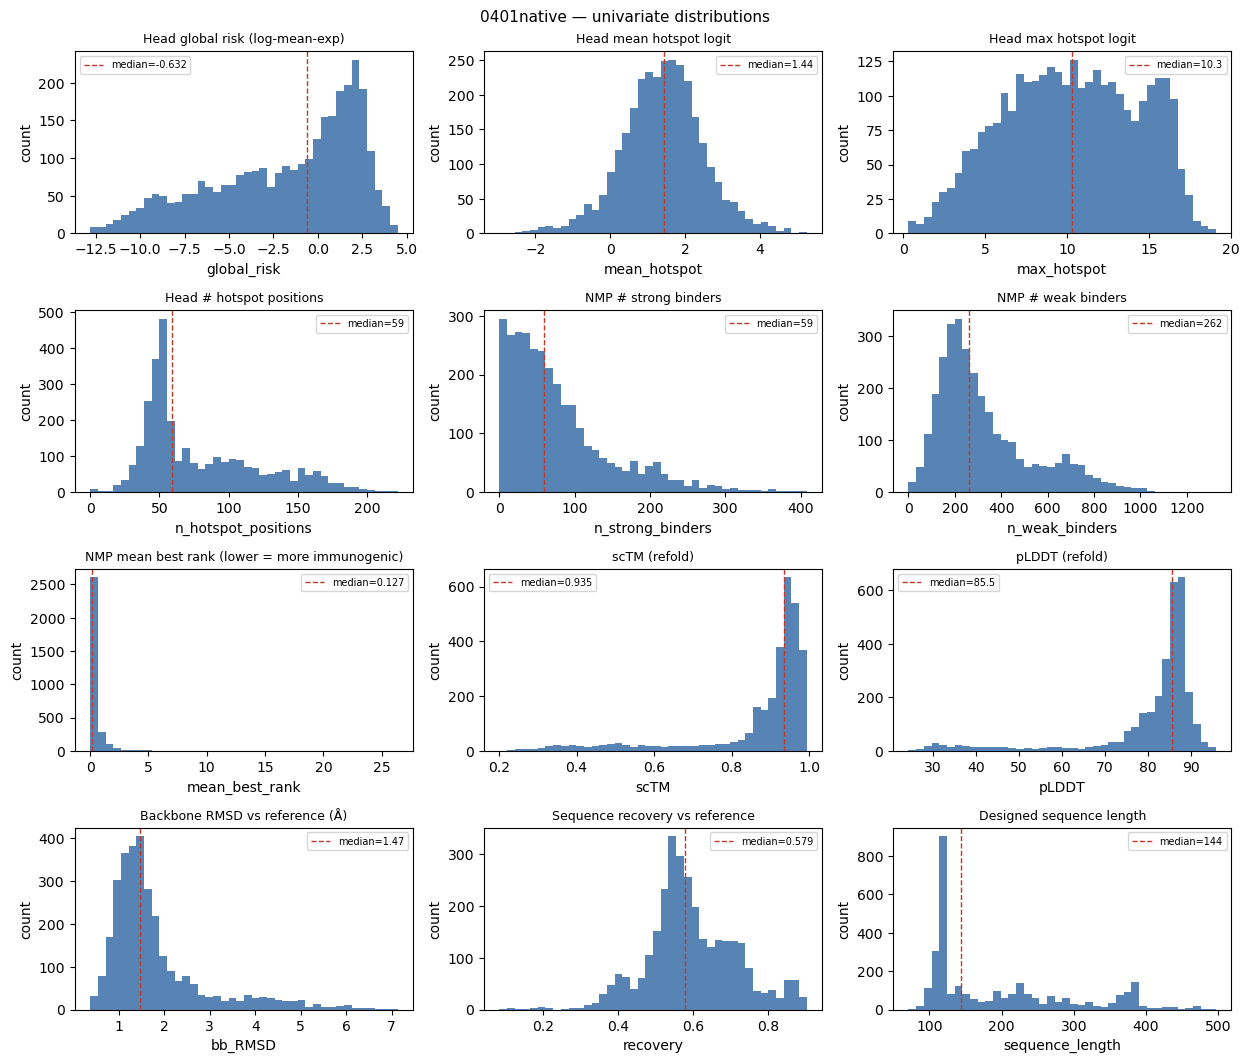

In [4]:
# Cell 4 — univariate distributions.
metrics = [
    ("global_risk",          "Head global risk (log-mean-exp)"),
    ("mean_hotspot",         "Head mean hotspot logit"),
    ("max_hotspot",          "Head max hotspot logit"),
    ("n_hotspot_positions",  "Head # hotspot positions"),
    ("n_strong_binders",     "NMP # strong binders"),
    ("n_weak_binders",       "NMP # weak binders"),
    ("mean_best_rank",       "NMP mean best rank (lower = more immunogenic)"),
    ("scTM",                 "scTM (refold)"),
    ("pLDDT",                "pLDDT (refold)"),
    ("bb_RMSD",              "Backbone RMSD vs reference (Å)"),
    ("recovery",             "Sequence recovery vs reference"),
    ("sequence_length",      "Designed sequence length"),
]
ncols = 3
nrows = (len(metrics) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.7 * nrows))
for ax, (col, title) in zip(axes.ravel(), metrics):
    vals = df[col].dropna()
    ax.hist(vals, bins=40, color="#3b6ea8", alpha=0.85)
    ax.axvline(vals.median(), color="#c0392b", linewidth=1.0, linestyle="--", label=f"median={vals.median():.3g}")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(col); ax.set_ylabel("count")
    ax.legend(fontsize=7, loc="best")
for ax in axes.ravel()[len(metrics):]:
    ax.axis("off")
fig.suptitle(f"{RUN_LABEL} — univariate distributions", fontsize=11)
fig.tight_layout()
plt.show()

In [5]:
# Cell 5 — foldability split: do folded designs differ from failed ones?
if df["foldability"].nunique() > 1:
    split = df.groupby("foldability")[STRUCT_METRICS + IMM_HEAD_METRICS + ["mean_best_rank", "n_strong_binders"]].agg(["median", "mean", "count"])
    print(split.to_string())
else:
    print(f"foldability is uniform: {df['foldability'].iloc[0]}")

                scTM                      pLDDT                  bb_RMSD                  recovery                 sequence_length                   global_risk                 mean_hotspot                 max_hotspot                  n_hotspot_positions                  mean_best_rank                 n_strong_binders                  
              median      mean count     median       mean count  median      mean count    median      mean count          median        mean count      median      mean count       median      mean count      median       mean count              median       mean count         median      mean count           median        mean count
foldability                                                                                                                                                                                                                                                                                                                         

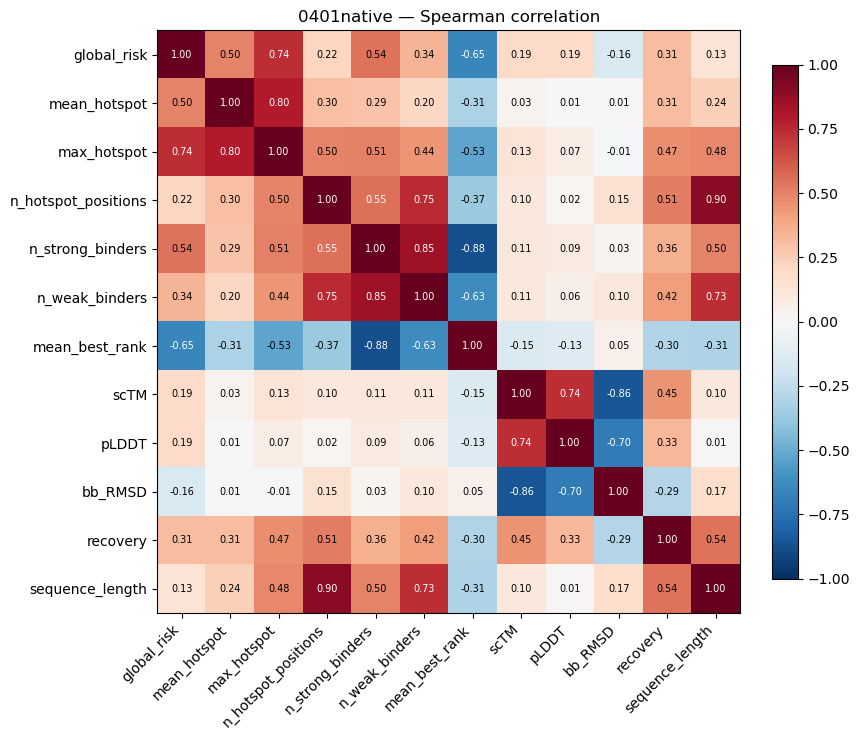

In [6]:
# Cell 6 — cross-metric Spearman correlation (rank-based, robust to skew).
corr_cols = [
    "global_risk", "mean_hotspot", "max_hotspot", "n_hotspot_positions",
    "n_strong_binders", "n_weak_binders", "mean_best_rank",
    "scTM", "pLDDT", "bb_RMSD", "recovery", "sequence_length",
]
corr = df[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="black" if abs(corr.iloc[i, j]) < 0.55 else "white")
fig.colorbar(im, ax=ax, fraction=0.04)
ax.set_title(f"{RUN_LABEL} — Spearman correlation")
fig.tight_layout()
plt.show()

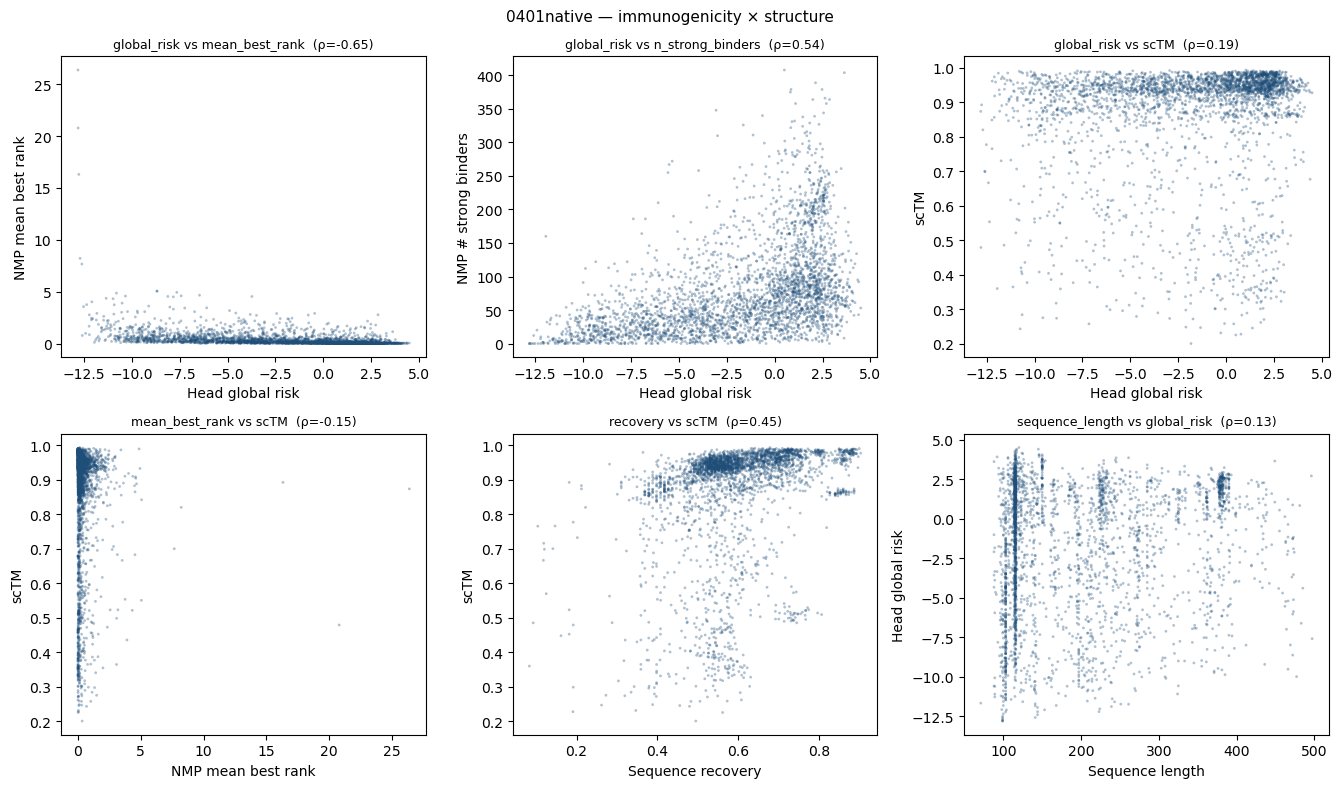

In [7]:
# Cell 7 — key joint scatters: head vs NMP, head vs scTM, recovery vs scTM.
pairs = [
    ("global_risk", "mean_best_rank", "Head global risk", "NMP mean best rank"),
    ("global_risk", "n_strong_binders", "Head global risk", "NMP # strong binders"),
    ("global_risk", "scTM",        "Head global risk", "scTM"),
    ("mean_best_rank", "scTM",     "NMP mean best rank", "scTM"),
    ("recovery", "scTM",           "Sequence recovery", "scTM"),
    ("sequence_length", "global_risk", "Sequence length", "Head global risk"),
]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.0))
for ax, (xc, yc, xl, yl) in zip(axes.ravel(), pairs):
    ax.scatter(df[xc], df[yc], s=4, alpha=0.35, color="#1f4e79", edgecolors="none")
    rho = df[[xc, yc]].corr(method="spearman").iloc[0, 1]
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f"{xc} vs {yc}  (ρ={rho:.2f})", fontsize=9)
fig.suptitle(f"{RUN_LABEL} — immunogenicity × structure", fontsize=11)
fig.tight_layout()
plt.show()

In [8]:
# Cell 8 — per-protein leaderboards.
n_show = 20
rank_cols = ["protein_id", "sequence_length", "global_risk", "mean_best_rank",
             "n_strong_binders", "scTM", "pLDDT", "recovery", "foldability"]
print("--- Lowest head global_risk (most safe by head) ---")
print(df.nsmallest(n_show, "global_risk")[rank_cols].to_string(index=False))
print("\n--- Highest head global_risk (most immunogenic by head) ---")
print(df.nlargest(n_show, "global_risk")[rank_cols].to_string(index=False))
print("\n--- Highest scTM (best refold) ---")
print(df.nlargest(n_show, "scTM")[rank_cols].to_string(index=False))
print("\n--- Foldability failures ---")
print(df.loc[~df["foldability"], rank_cols].head(n_show).to_string(index=False))

--- Lowest head global_risk (most safe by head) ---
protein_id  sequence_length  global_risk  mean_best_rank  n_strong_binders    scTM     pLDDT  recovery  foldability
    3MQ7_H               99   -12.809675          26.370                 0 0.87398 86.245711  0.212121         True
    3MQ7_G               99   -12.802719          20.782                 0 0.47939 72.374856  0.191919        False
    3MQ7_L               99   -12.764618          16.310                 0 0.89287 88.650430  0.181818         True
    3MQ7_E               99   -12.699421           8.216                 0 0.82042 86.806320  0.222222         True
    3MQ7_J               99   -12.604066           7.664                 0 0.70046 87.958905  0.141414         True
    4CPC_D              141   -12.585797           0.780                12 0.69894 86.470614  0.120567         True
    3MQ7_A               99   -12.518230           3.560                 0 0.77756 87.627234  0.191919         True
    4CPC_C          

In [9]:
# Cell 9 — export merged table for downstream comparison (e.g., C1 vs C0 deltas).
OUT_DIR = Path(os.environ.get("NOTEBOOK_OUT_DIR", PROJECT_ROOT / "notebooks" / "outputs"))
OUT_DIR.mkdir(parents=True, exist_ok=True)
merged_path = OUT_DIR / f"{RUN_LABEL}_merged.parquet"
df.to_parquet(merged_path, index=False)
print(f"wrote {merged_path}  ({len(df)} rows, {len(df.columns)} cols)")

wrote /Users/jerry/Project/MHC-IF/notebooks/outputs/0401native_merged.parquet  (3072 rows, 19 cols)
